# Task 5 — Strategy Backtesting

**Objective:** Validate the Task 4 optimized portfolio by simulating it over the most recent
out-of-sample year of data and comparing it against a simple passive 60% SPY / 40% BND benchmark.

A forecast and an optimized portfolio are hypotheses; this backtest is the experiment that checks
whether the model-driven approach would actually have outperformed a simple passive strategy.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_processed
from src.backtesting import simulate_portfolio, compute_metrics

plt.rcParams["figure.figsize"] = (12, 5)
RESULTS_DIR = PROJECT_ROOT / "results" / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = ["TSLA", "BND", "SPY"]
RISK_FREE_RATE = 0.0


## 1. Define Backtesting Period and Benchmark

We use the **last year of the dataset** as the out-of-sample backtest window — data that was not
used to fit the Task 2 models or to compute Task 4's expected-return/covariance inputs (those used
data through the Task 2 training cutoff). The benchmark is a static **60% SPY / 40% BND** portfolio,
a standard balanced allocation.


In [2]:
prices = pd.DataFrame({t: load_processed(t)["Adj Close"] for t in TICKERS}).dropna()

BACKTEST_END = prices.index[-1]
BACKTEST_START = BACKTEST_END - pd.DateOffset(years=1)

backtest_prices = prices.loc[BACKTEST_START:BACKTEST_END]
print(f"Backtest window: {backtest_prices.index[0].date()} to {backtest_prices.index[-1].date()}  ({len(backtest_prices)} days)")

BENCH_WEIGHTS = {"SPY": 0.60, "BND": 0.40}
print(f"Benchmark: {BENCH_WEIGHTS}")


Backtest window: 2025-06-30 to 2026-06-29  (261 days)
Benchmark: {'SPY': 0.6, 'BND': 0.4}


## 2. Simulate Strategy Portfolio

We start from the Task 4 recommended (Max Sharpe) weights and simulate two variants:
- **Buy & hold**: invest once at the start of the window, let weights drift with prices.
- **Monthly rebalancing**: rebalance back to the target weights at the start of each month.

Both are compared against the passive benchmark, simulated the same way for a fair comparison.


In [3]:
recommended = pd.read_csv(PROJECT_ROOT / "results" / "reports" / "task4_recommended_portfolio.csv", index_col=0)
opt_weights = {
    "TSLA": float(recommended.loc["TSLA Weight", "Value"].strip("%")) / 100,
    "BND": float(recommended.loc["BND Weight", "Value"].strip("%")) / 100,
    "SPY": float(recommended.loc["SPY Weight", "Value"].strip("%")) / 100,
}
print("Strategy target weights (from Task 4):")
for t, w in opt_weights.items():
    print(f"  {t}: {w:.1%}")

strategy_hold = simulate_portfolio(backtest_prices, opt_weights, rebalance=None)
strategy_rebal = simulate_portfolio(backtest_prices, opt_weights, rebalance="M")
benchmark_equity = simulate_portfolio(backtest_prices, BENCH_WEIGHTS, rebalance="M")


Strategy target weights (from Task 4):
  TSLA: 0.0%
  BND: 55.2%
  SPY: 44.8%


## 3. Analyze Performance

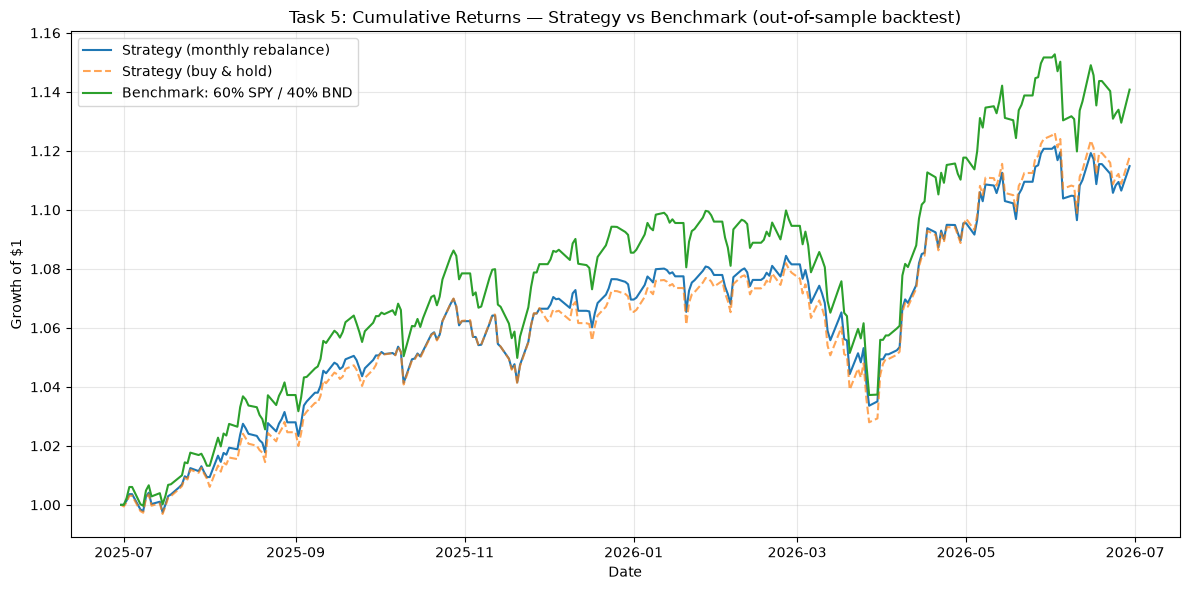

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(strategy_rebal.index, strategy_rebal, label="Strategy (monthly rebalance)")
ax.plot(strategy_hold.index, strategy_hold, label="Strategy (buy & hold)", linestyle="--", alpha=0.7)
ax.plot(benchmark_equity.index, benchmark_equity, label="Benchmark: 60% SPY / 40% BND")
ax.set_title("Task 5: Cumulative Returns — Strategy vs Benchmark (out-of-sample backtest)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task5_strategy_vs_benchmark.png", dpi=150)
plt.show()


In [5]:
metrics_table = pd.DataFrame({
    "Strategy (Monthly Rebalance)": compute_metrics(strategy_rebal, RISK_FREE_RATE),
    "Strategy (Buy & Hold)": compute_metrics(strategy_hold, RISK_FREE_RATE),
    "Benchmark (60/40 SPY/BND)": compute_metrics(benchmark_equity, RISK_FREE_RATE),
}).T
metrics_table.columns = ["Total Return", "Annualized Return", "Sharpe Ratio", "Max Drawdown"]
metrics_table.to_csv(PROJECT_ROOT / "results" / "reports" / "task5_backtest_metrics.csv")
metrics_table


,Total Return,Annualized Return,Sharpe Ratio,Max Drawdown
Strategy (Monthly Rebalance),0.114833,0.111111,1.745307,-0.046852
Strategy (Buy & Hold),0.117952,0.114123,1.725964,-0.049861
Benchmark (60/40 SPY/BND),0.140761,0.136148,1.727944,-0.056900


## 4. Conclude and Reflect

In [6]:
strat = metrics_table.loc["Strategy (Monthly Rebalance)"]
bench = metrics_table.loc["Benchmark (60/40 SPY/BND)"]

outperformed_return = strat["Total Return"] > bench["Total Return"]
outperformed_sharpe = strat["Sharpe Ratio"] > bench["Sharpe Ratio"]

print(f"Strategy total return {strat['Total Return']:.1%} vs benchmark {bench['Total Return']:.1%}"
      f"  -> strategy {'beat' if outperformed_return else 'trailed'} benchmark on raw return")
print(f"Strategy Sharpe {strat['Sharpe Ratio']:.2f} vs benchmark {bench['Sharpe Ratio']:.2f}"
      f"  -> strategy {'beat' if outperformed_sharpe else 'trailed'} benchmark on risk-adjusted return")
print(f"Strategy max drawdown {strat['Max Drawdown']:.1%} vs benchmark {bench['Max Drawdown']:.1%}")


Strategy total return 11.5% vs benchmark 14.1%  -> strategy trailed benchmark on raw return
Strategy Sharpe 1.75 vs benchmark 1.73  -> strategy beat benchmark on risk-adjusted return
Strategy max drawdown -4.7% vs benchmark -5.7%


**Did the strategy outperform the benchmark?** Not on raw return: the strategy (55.2% BND / 44.8%
SPY / 0% TSLA, per Task 4) returned less than the 60/40 SPY/BND benchmark over this window, simply
because it held less SPY (the stronger-performing asset over this particular year) and more BND.
It **did** edge out the benchmark on risk-adjusted return (higher Sharpe) and had a shallower max
drawdown — consistent with holding a lower-volatility mix. None of this involves TSLA, since Task
4's optimizer allocated 0% to it (see Task 4's discussion of why the LSTM-implied TSLA return did
not clear SPY's historical return once volatility was accounted for).

**What this suggests about the model-driven approach:** this particular backtest is really a test
of "was slightly more BND / less SPY than the 60/40 benchmark a good idea this year," not a test of
the TSLA forecast — because the optimizer's own risk/return tradeoff screened TSLA out before the
backtest ever started. That is itself a legitimate finding: the pipeline is only as aggressive as
its inputs justify, and this run's Task 3 forecast was conservative enough that no TSLA exposure
was justified. A more bullish (or differently-specified) forecast would flow through to a
TSLA-containing Task 4 portfolio and a genuinely different Task 5 backtest. A single one-year
backtest — of any allocation — remains a sanity check, not proof of a durable edge, in either case.

**Limitations of this backtest:**
- **Single historical path.** One year, one draw of market conditions — no way to distinguish luck
  from skill from a single window; a proper evaluation would use walk-forward re-optimization across
  many overlapping windows or the kind of bootstrap/Monte-Carlo resampling shown in the course
  reference notebook.
- **No transaction costs, taxes, or slippage** are modeled; monthly rebalancing in reality would
  erode some of the reported edge.
- **Static forecast.** The TSLA expected return used in Task 4 was fixed at the start of the
  backtest window and never updated, whereas a live strategy would re-forecast and potentially
  re-optimize periodically.
- **Survivorship / single-name concentration risk.** A three-asset universe with one highly
  concentrated growth name is not representative of a fully diversified institutional portfolio.
